# Demo: ROC, Entity Tile and No-Skill Performances

In [1]:
%matplotlib tk

## All imports

In [2]:
import time
from threading import Condition

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

from sorbetto.annotation import AnnotationCurveFixedClassPriors
from sorbetto.flavor import EntityFlavor
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.ranking import Entity
from sorbetto.tile import EntityTile

## Configuration

In [3]:
initial_prior_pos = 0.5
initial_fpr = 0.1
initial_tpr = 0.9

## The data

In [4]:
cv = Condition()

# We will use the default parameterization for drawing the Tile
parameterization = ParameterizationDefault()

prior_pos = None
prior_neg = None
fpr = None
tpr = None

e_no_skill_neg = None
e_no_skill_pos = None

annotation = None

should_redraw_all = False

locked = True

## The setters, to be called in the GUI thread (or to initialize in the main thread)

In [ ]:
def set_prior_pos(value_prior_pos):
    print("setting prior pos to", value_prior_pos)
    global prior_pos
    global prior_neg
    global e_no_skill_neg
    global e_no_skill_pos
    global annotation
    with cv:
        prior_pos = value_prior_pos
        prior_neg = 1.0 - prior_pos
        p_no_skill_neg = TwoClassClassificationPerformance.getNoSkill(
            priorPos=prior_pos, ratePos=0.0
        )
        p_no_skill_pos = TwoClassClassificationPerformance.getNoSkill(
            priorPos=prior_pos, ratePos=1.0
        )
        e_no_skill_neg = Entity(p_no_skill_neg, r"$\mathcal{C}_-$", color="lightsalmon")
        e_no_skill_pos = Entity(p_no_skill_pos, r"$\mathcal{C}_+$", color="lightgreen")
        annotation = AnnotationCurveFixedClassPriors(
            prior_pos, color="k", linestyle=":"
        )


def set_fpr_tpr(value_fpr, value_tpr):
    print("setting fpr to", value_fpr)
    print("setting tpr to", value_tpr)
    global fpr
    global tpr
    with cv:
        fpr = value_fpr
        tpr = value_tpr


def toggle_lock():
    global locked
    with cv:
        locked = not locked


def redraw_all_asap():
    print("asking to redraw all asap")
    global should_redraw_all
    with cv:
        should_redraw_all = True
        cv.notify()

## Create figure

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))
plt.subplots_adjust(bottom=0.25)  # leave space for sliders

prior_pos_ax = fig.add_axes([0.2, 0.1, 0.6, 0.03])
prior_pos_slider = Slider(
    ax=prior_pos_ax,
    label=r"$\pi_+ = P(Y=c_+)$",
    valmin=0.0,
    valmax=1.0,
    valinit=initial_prior_pos,
    valstep=0.01,
    orientation="horizontal",
)

txt = "Click anywhere on ROC or drag-and-drop the blue point to update the performance"
fig.suptitle(txt, fontweight="bold", fontstyle="italic")

set_prior_pos(initial_prior_pos)
set_fpr_tpr(initial_fpr, initial_tpr)
redraw_all_asap()

setting prior pos to 0.5
setting fpr to 0.1
setting tpr to 0.9
asking to redraw all asap


## The updater thread

In [ ]:
def get_performance():
    with cv:
        ptn = prior_neg * (1.0 - fpr)
        pfp = prior_neg * fpr
        pfn = prior_pos * (1.0 - tpr)
        ptp = prior_pos * tpr
        p = TwoClassClassificationPerformance(ptn, pfp, pfn, ptp)
        return p


# Drawing the Tile with ranking frontiers
def draw_entity_tile(fig, ax, p):
    e = Entity(p, r"$\mathcal{C}$", color="lightskyblue")
    flavor = EntityFlavor(entity_list=[e, e_no_skill_neg, e_no_skill_pos], rank=1)

    tile = EntityTile(
        parameterization=parameterization, flavor=flavor, disable_legend=True
    )
    tile.appendAnnotation(annotation)
    tile.draw(fig, ax)


# Drawing the ranking ladder induced by a specific score
def draw_roc(fig, ax, p):
    p.drawInROC(
        fig,
        ax,
        show_priors=False,
        show_unbiased=False,
        show_opposite_unbiased=False,
        color_classifier="lightskyblue",
        color_classifier_neg="lightsalmon",
        color_classifier_pos="lightgreen",
        color_classifier_opp="none",
    )


def updater_thread_job():
    global should_redraw_all
    while True:
        with cv:
            while not should_redraw_all:
                print("waiting ...")
                cv.wait()
            should_redraw_all = False
        print("redrawing now")
        p = get_performance()
        if False:
            ax[0].clear()
            draw_entity_tile(fig, ax[0], p)
            ax[1].clear()
            draw_roc(fig, ax[1], p)
            fig.canvas.draw_idle()


# updater_thread = Thread(target=updater_thread_job, daemon=True).start()

## Register all methods to be executed in the GUI thread

In [8]:
import threading


def update_motion_notify(event):
    print("update_motion_notify in", threading.current_thread().name)
    if event.inaxes != ax[1]:
        return
    with cv:
        if locked:
            return
    set_fpr_tpr(event.xdata, event.ydata)
    redraw_all_asap()


plt.connect("motion_notify_event", update_motion_notify)


def update_button_release(event):
    print("update_button_release in", threading.current_thread().name)
    if event.inaxes != ax[1]:
        return
    toggle_lock()
    update_motion_notify(event)


plt.connect("button_release_event", update_button_release)


def prior_pos_changed(_=None):
    print("prior_pos_changed in", threading.current_thread().name)
    value = prior_pos_slider.val
    if value < 0.01:
        value = 0.01
        prior_pos_slider.set_val(value)
    if value > 0.99:
        value = 0.99
        prior_pos_slider.set_val(value)
    set_prior_pos(value)
    redraw_all_asap()


prior_pos_slider.on_changed(prior_pos_changed)

0

## Generate thumbnail

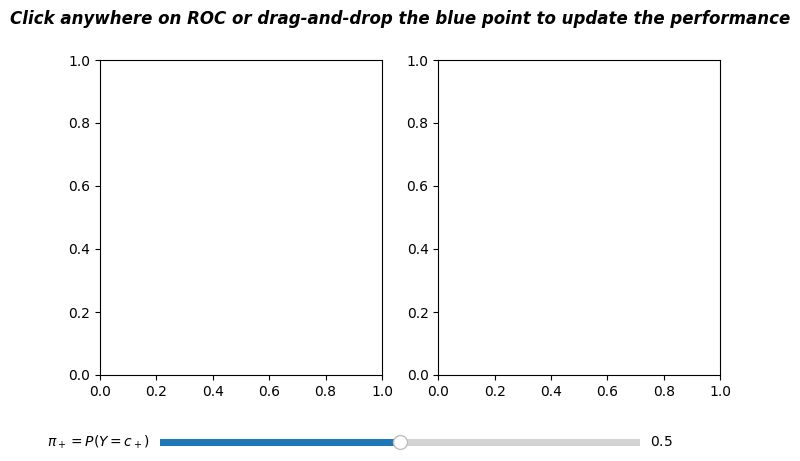

In [9]:
time.sleep(1.0)  # Be sure that everything has been redrawn
fig